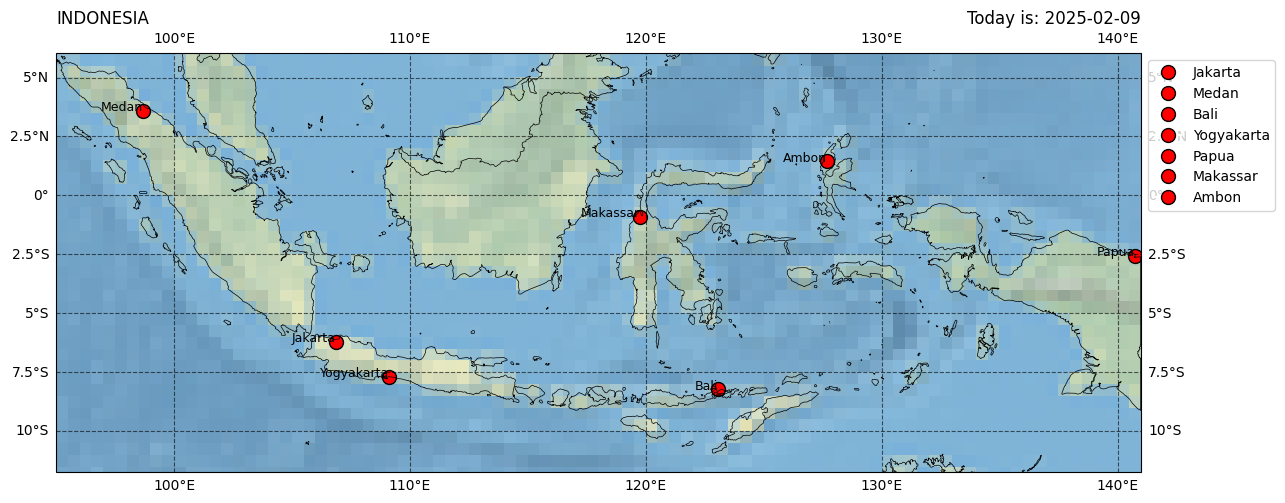

In [7]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import date
from matplotlib.lines import Line2D

# Membuat figure dengan proyeksi PlateCarree
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.stock_img()

# Menambahkan garis pantai dan perbatasan
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', linewidth=0.5)

# Menentukan batas wilayah fokus pada Indonesia
ax.set_extent([95, 141, -11, 6])
ax.gridlines(draw_labels=True, color='black', alpha=0.6, linestyle='--')

# Contoh data gempa bumi (koordinat, magnitudo, dan nama daerah)
earthquake_data = {
    'latitude': [-6.21, 3.58, -8.22, -7.69, -2.55, -0.92, 1.44],
    'longitude': [106.85, 98.68, 123.05, 109.12, 140.72, 119.75, 127.68],
    'name': ['Jakarta', 'Medan', 'Bali', 'Yogyakarta', 'Papua', 'Makassar', 'Ambon']
}

# Menambahkan titik-titik gempa bumi
scatter = ax.scatter(
    earthquake_data['longitude'],
    earthquake_data['latitude'],
    c='red',
    s=100,
    edgecolors='k',
    transform=ccrs.PlateCarree()
)

# Menambahkan nama daerah sebagai teks di dekat titik
for lon, lat, name in zip(earthquake_data['longitude'], earthquake_data['latitude'], earthquake_data['name']):
    ax.text(lon, lat, name, transform=ccrs.PlateCarree(), fontsize=9, ha='right')

# Membuat elemen-elemen legenda
legend_elements = [Line2D([0], [0], marker='o', color='w', label=name,
                          markerfacecolor='red', markersize=10, markeredgecolor='k')
                   for name in earthquake_data['name']]

# Menambahkan legenda di sebelah kanan peta
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# Menambahkan judul
ax.set_title("INDONESIA", loc='left')
ax.set_title(f"Today is: {date.today()}", loc='right')

# Menampilkan plot
plt.show()


c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
c:\Users\agung\OneDrive\Documents\venv\Agung\venv\Lib\site-packages\cartopy\io\__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


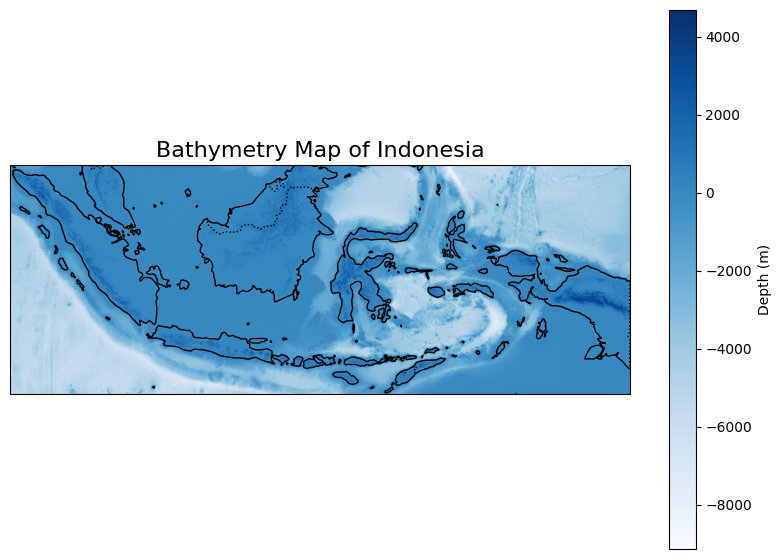

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from rasterio.plot import show
import rasterio

# Load TIFF file
tiff_file = "indonesia.tif"  # Ganti dengan lokasi file TIFF Anda
with rasterio.open(tiff_file) as src:
    bathymetry_data = src.read(1)  # Membaca band pertama
    extent = src.bounds  # Mendapatkan batas geografis (min lon, min lat, max lon, max lat)

# Plot data dengan Cartopy
fig, ax = plt.subplots(
    figsize=(10, 10),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([95, 141, -11, 6], crs=ccrs.PlateCarree())  # Batas peta Indonesia

# Menampilkan data bathimetri
img = ax.imshow(
    bathymetry_data,
    extent=[extent.left, extent.right, extent.bottom, extent.top],
    cmap="Blues",  # Warna untuk bathimetri
    origin="upper",
    transform=ccrs.PlateCarree()
)

# Tambahkan garis pantai dan fitur lain
ax.add_feature(cfeature.COASTLINE, linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")

# Tambahkan colorbar
cbar = plt.colorbar(img, ax=ax, orientation="vertical", shrink=0.7, label="Depth (m)")

# Tambahkan judul
ax.set_title("Bathymetry Map of Indonesia", fontsize=16)

plt.show()


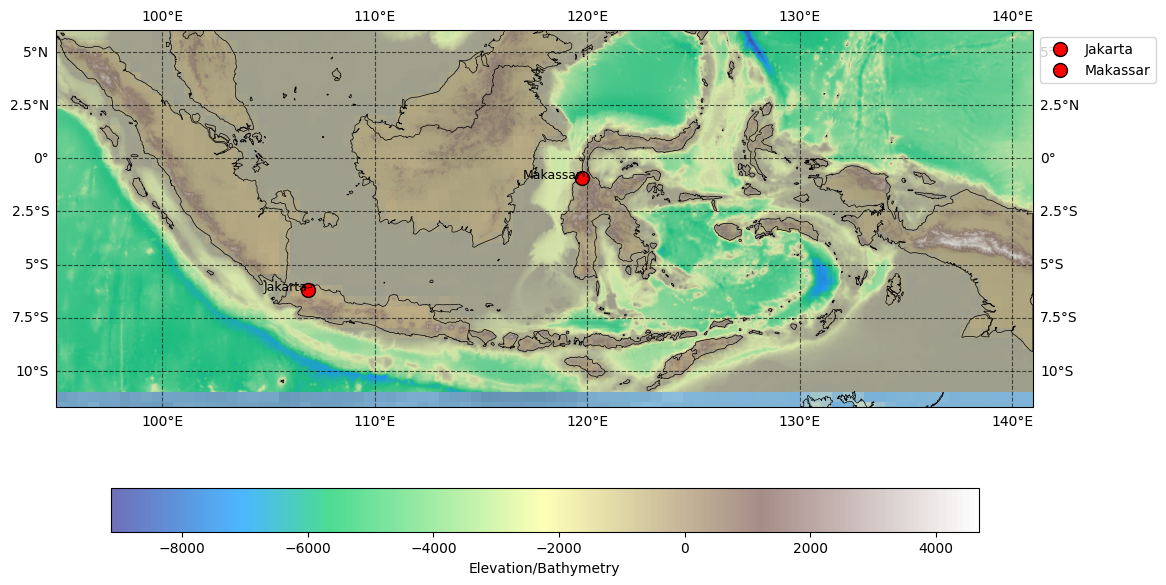

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import date
from matplotlib.lines import Line2D
import rasterio

# Load TIFF file (misalnya bathymetri atau elevasi)
tiff_file = "indonesia.tif" 
with rasterio.open(tiff_file) as src:
    tiff_data = src.read(1)  # Membaca band pertama
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]  # Batas geografis TIFF

# Membuat figure dengan proyeksi PlateCarree
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())
ax.stock_img()

# Menambahkan garis pantai dan perbatasan
ax.add_feature(cfeature.COASTLINE.with_scale('10m'), edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.BORDERS.with_scale('10m'), edgecolor='black', linewidth=0.5)

# Menentukan batas wilayah fokus pada Indonesia
ax.set_extent([95, 141, -11, 6])
ax.gridlines(draw_labels=True, color='black', alpha=0.6, linestyle='--')

# Menampilkan data TIFF sebagai latar belakang
img = ax.imshow(
    tiff_data,
    extent=extent,
    origin="upper",
    cmap="terrain",  # Pilih colormap (misalnya 'terrain' atau 'Blues')
    transform=ccrs.PlateCarree(),
    alpha=0.7  # Transparansi untuk memadukan dengan elemen lain
)

# Menambahkan colorbar untuk TIFF
cbar = plt.colorbar(img, ax=ax, orientation="horizontal", shrink=0.8, label="Elevation/Bathymetry")

# Contoh data gempa bumi (koordinat, magnitudo, dan nama daerah)
earthquake_data = {
    'latitude': [-6.21, -0.92],
    'longitude': [106.85, 119.75],
    'name': ['Jakarta', 'Makassar']
}

# Menambahkan titik-titik gempa bumi
scatter = ax.scatter(
    earthquake_data['longitude'],
    earthquake_data['latitude'],
    c='red',
    s=100,
    edgecolors='k',
    transform=ccrs.PlateCarree()
)

# Menambahkan nama daerah sebagai teks di dekat titik
for lon, lat, name in zip(earthquake_data['longitude'], earthquake_data['latitude'], earthquake_data['name']):
    ax.text(lon, lat, name, transform=ccrs.PlateCarree(), fontsize=9, ha='right')

# Membuat elemen-elemen legenda
legend_elements = [Line2D([0], [0], marker='o', color='w', label=name,
                          markerfacecolor='red', markersize=10, markeredgecolor='k')
                   for name in earthquake_data['name']]

# Menambahkan legenda di sebelah kanan peta
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

# Menampilkan plot
plt.show()
